### RNN (순환 신경망)
- 이전 시점의 정보를 현재 시점의 계산에 반영하는 구조

    - 첫번째 입력
        - 초기 상태(h_0 = 0)와 입력에 대한 상태(h_1)로 계산
    - 두번째 입력
        - 이전의 상태(h_1)와 결합해서 계산 (h_2)
    - 세번째 입력
        - 이전의 입력상태 (h_2)와 현재의 입력상태를 결합해서 계산(h_3)
    - ...
    - 반복 작업이 완료되었을떄
        - 마지막 상태 (h_t) 생성 -> 모든 과거의 정보를 결합해놓은 상태

- parameter
    - input_size
        - 각 시점(레이어)에서 입력 feature의 수
    - hidden_size
        - 은닉츧(출력)의 크기
    - num_layers
        - 기본값 : 1
        - RNN 층의 개수 (층이 깊어질수록 복잡한 패턴을 발생)
        - 층의 개수가 늘어날수록 시간은 증가하고 과적합의 위험성이 존재
        - 1 ~ 3 정도 사용을 하고 1부터 개수를 1씩 증가시키면서 사용
    - nonlinearity
        - 기본값 : 'tanh'
        - 비선형 활성화 함수를 선택
    - bath_first
        - 기본값 : False
        - 입력 텐서에서 첫번째 차원이 배치인지 여부
    - bias
        - 기본값 : True
        - 각 가중치의 편향을 추가할지의 여부
    - dropout
        - 기본값 : 0.0
        - 층 사이에 Dropout의 적용 비울 : 층이 2개 이상인 경우에만 사용
    - bidirectional
        - 기본값 : False
        - 양방향 RNN을 사용할지의 여부 (순방향은 기본, 역방향을 사용할 것인가?)

- parameter 설정시 유의할 점
    - hidden_size
        - 너무 작은 경우라면 정보가 부족, 너무 큰 경우라면 과적합
        - 일반적으로 32, 64, 128
    - num_layers
        - 시간의 복잡도에 따라서 1 ~ 3 정도를 이용
        - 1부터 테스트를 돌려서 교차 검증
    - nonlinearity
        - 일반적으로 'tanh'을 사용
        - relu를 사용하면 시간이 갑소하지만 발산의 위험성이 증가
    - dropout
        - 층이 2개 이상인 경우에만 사용
        - 과적합 방지를 위해 사용, 0.2 ~ 0.5 사이의 값을 사용 (권장사항)

In [2]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
#랜덤 시드 고정
np.random.seed(42)
torch.manual_seed(42)

In [4]:
#노이즈를 포함한 연속성을 가진 sin 곡선을 생성
x=torch.arange(3000).float()
y=torch.sin(2 * math.pi * 0.02 * x) + 0.05 * torch.randn(3000)

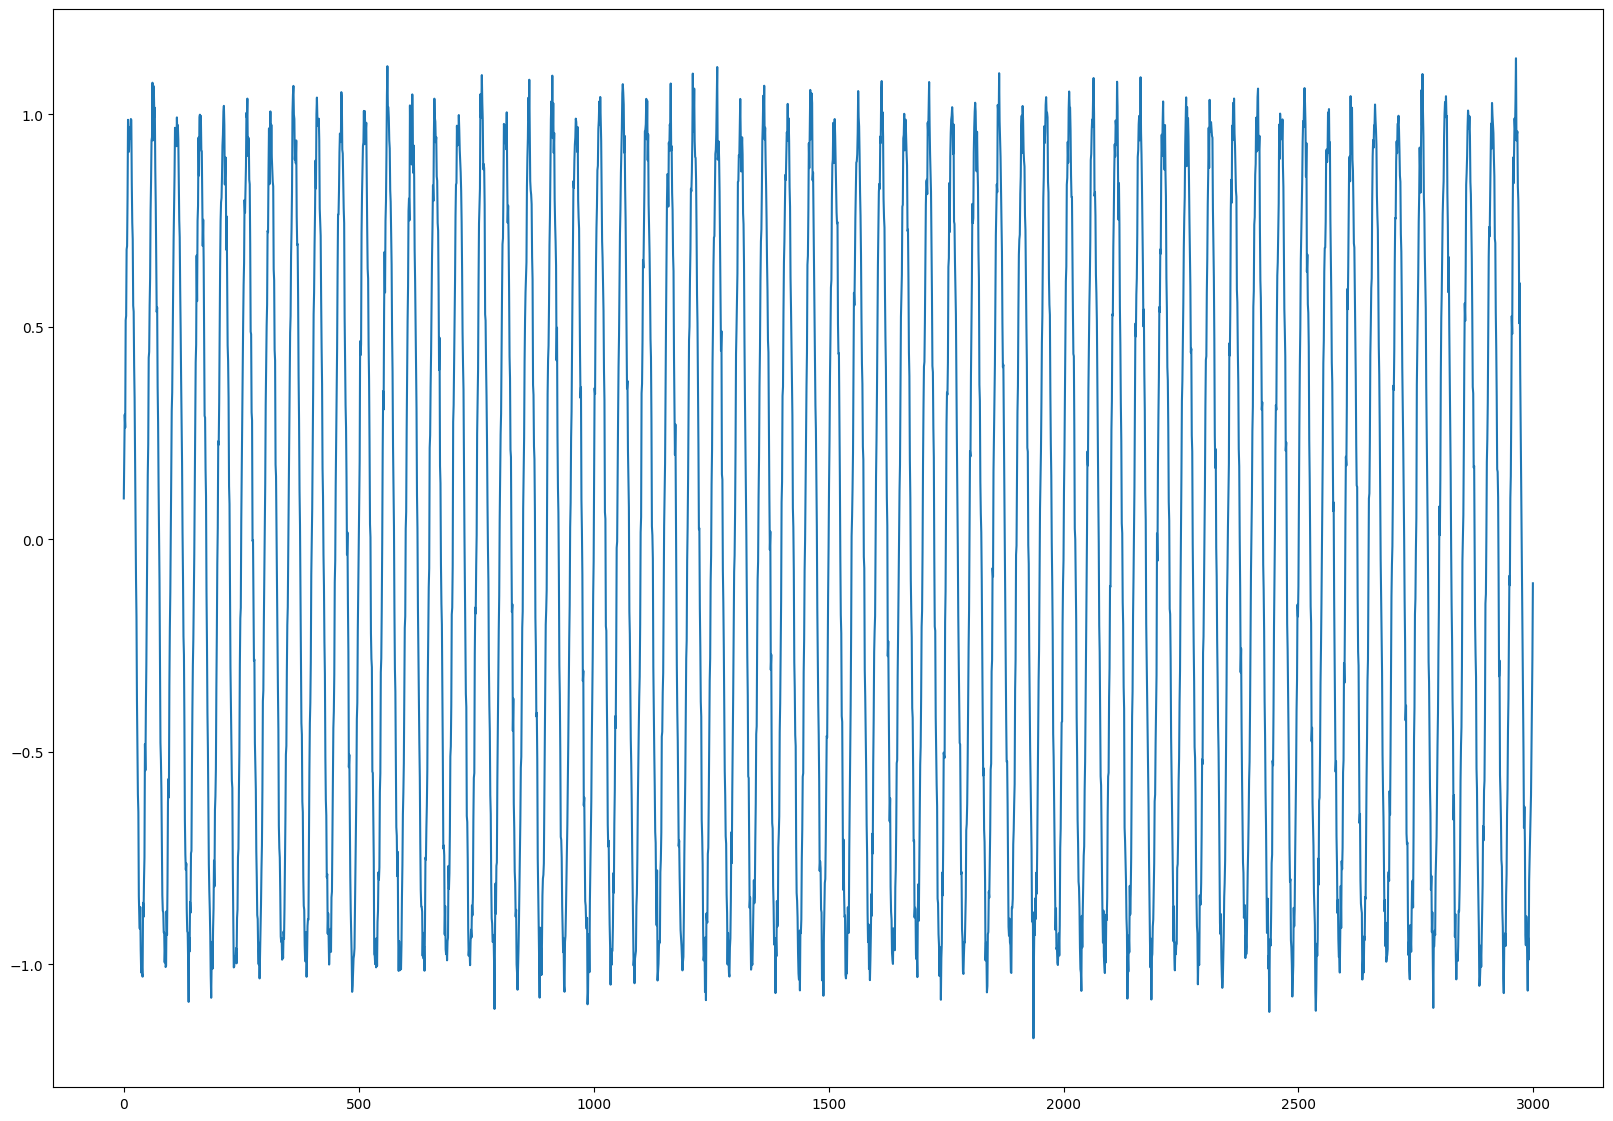

In [5]:
plt.figure(figsize=(20,14))
plt.plot(x, y)
plt.show()

In [6]:
#train, test 데이터 셋 분할 8 : 2 -> 앞의 80%가 train, 뒤의 20%가 test
train_size=int(0.8 * len(x))
train_size

2400

In [10]:
# X_train=x[:train_size]
X_train=y[:train_size]
# y_train=y[:train_size]
X_test=y[train_size:]

In [11]:
X_test

tensor([ 0.0207,  0.0991,  0.2554,  0.3119,  0.5472,  0.5841,  0.7407,  0.7583,
         0.8579,  0.8834,  0.9923,  0.9123,  0.9639,  1.0407,  1.0607,  0.9211,
         0.9168,  0.9495,  0.7320,  0.6089,  0.5676,  0.4596,  0.3048,  0.3229,
         0.1151, -0.0594, -0.1183, -0.2164, -0.3797, -0.4620, -0.5946, -0.6721,
        -0.7896, -0.9260, -0.9211, -0.8456, -1.0102, -0.9786, -1.1119, -0.9636,
        -0.9407, -0.9556, -0.8743, -0.7616, -0.7417, -0.5208, -0.5316, -0.3982,
        -0.2048, -0.0887,  0.0137,  0.2113,  0.3159,  0.3049,  0.5043,  0.6208,
         0.6519,  0.7261,  0.7903,  0.9761,  0.8950,  1.0019,  0.9735,  0.9836,
         0.9721,  0.9413,  0.9882,  0.8780,  0.8291,  0.6856,  0.5420,  0.4927,
         0.4309,  0.2083,  0.2284,  0.0152, -0.1984, -0.2588, -0.3666, -0.4672,
        -0.5668, -0.7253, -0.8053, -0.7994, -0.9430, -0.9609, -1.0005, -1.0757,
        -1.0411, -1.0023, -0.8670, -0.9104, -0.8716, -0.7442, -0.6498, -0.5512,
        -0.4016, -0.3324, -0.1535, -0.18

In [12]:
scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train.reshape(-1,1))
X_test_sc=scaler.transform(X_test.reshape(-1,1))

In [13]:
X_train_sc

array([[ 0.13549958],
       [ 0.28142013],
       [ 0.41417719],
       ...,
       [-0.56898224],
       [-0.31882725],
       [-0.10808127]], shape=(2400, 1))

In [14]:
X_train_tensor=torch.tensor(X_train_sc, dtype=torch.float32)
X_test_tensor=torch.tensor(X_test_sc, dtype=torch.float32)

In [15]:
X_train_tensor.shape

torch.Size([2400, 1])

In [16]:
#Tensor Data를 배치가 존재하는 3차원 데이터로 변환
X_train_tensor = X_train_tensor.unsqueeze(0)
X_test_tensor = X_test_tensor.unsqueeze(0)

X_train_tensor.shape
#(2400,1) -> (2400, 1, 1)

torch.Size([1, 2400, 1])

In [17]:
class RNN_Model(nn.Module):
    def __init__(self):
        super(RNN_Model, self).__init__()
        self.rnn=nn.RNN(
            input_size=1,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
            nonlinearity='tanh',
            bidirectional=False
        )
        self.linear=nn.Linear(64, 1)
    def forward(self,x):
        #RNN 모델에서 되돌려주는 데이터는 2개를 되돌려 줌
            #첫번쨰 데이터 : 모든 시점에서의 은닉층의 값 
            # 두번쩨 데이터 : 마지막 시점에서의 은닉층의 값 (층이 존재하는 경우 마지막 층의 값을 추출)
            out, h_n = self.rnn(x)
            result = self.linear(h_n[-1])
            return result

In [18]:
model=RNN_Model()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

### DataLoader
- pytorch에서 Dataset을 효율적으로 배치 단위로 꺼내주는 반복자
- 반복학습에서 루프에 맞는 형태의 데이터셋을 공급해주는 역할
- parameter
    - batch_size
        - Dataset들을 모아서 텐서의 형태로 묶어준다.
    - shuffle
        - 에폭마다 데이터의 순서를 랜덤하게 변경
    - drop_last
        - window(구간)에 맞는 구간을 나눠주고 마지막 구간에서 데이터의 개수가 window가 작은 경우에는 해당 배치를 제거
    - pin_memory
        - GPU 사용 시 True로 변경하면 CPU -> GPU 전송이 빨라짐

In [19]:
#Custom Dataset 클래스 정의
class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        #_data : 시계열 데이터
        #_window : 구간 설정
        self.data=_data
        self.window=_window
        #유효 샘플의 개수 계산
        #입력 데이터 : 전체 길이 - window 크기
        self.n = len(self.data) - self.window
    #__len__ 메서드 : 데이터 셋의 크기를 변환
    #__getitem__ 메서드 : 인덱스에 해당하는 샘플을 변환
    #특수 메서드 : DataLoader가 데이터셋에서 데이터를 불러올 때 자동으로 호출
    def __len__(self):
        return self.n
    def __getitem__(self,idx):
        # DataLoader가 실제로 입력이 된 데이터들을 스라이스해서 가지고 가는 함수
        #idx :0 // data[0 : 10] -> idx (0 ~ 9) -> 문제 데이터
        x=self.data[idx:idx + self.window]
        #data[10] : 11번쩨 데이터 -> 정답 데이터
        y=self.data[idx + self.window]
        return x, y

In [20]:
window=10
train_ds=WindowDataset(X_train_tensor.squeeze(0), window)

In [21]:
len(X_train_tensor.squeeze(0))

2400

In [22]:
len(train_ds)

2390

In [23]:
# train_ds.__getitem__(0)
train_ds[0]

(tensor([[0.1355],
         [0.2814],
         [0.4142],
         [0.3706],
         [0.7275],
         [0.7422],
         [0.9629],
         [0.9741],
         [1.1385],
         [1.3934]]),
 tensor([1.3145]))

In [24]:
train_ds.__getitem__(1)

(tensor([[0.2814],
         [0.4142],
         [0.3706],
         [0.7275],
         [0.7422],
         [0.9629],
         [0.9741],
         [1.1385],
         [1.3934],
         [1.3145]]),
 tensor([1.2873]))

In [25]:
batch_size = 10
x_list = []
y_list = []
for i in range(len(train_ds)):
    if i == 10 : 
        break
    x, y = train_ds[i]
    x_list.append(x)
    y_list.append(y)

y_list

[tensor([1.3145]),
 tensor([1.2873]),
 tensor([1.3572]),
 tensor([1.3691]),
 tensor([1.3321]),
 tensor([1.3961]),
 tensor([1.3929]),
 tensor([1.1803]),
 tensor([1.0522]),
 tensor([0.9970])]

In [26]:
train_dl=DataLoader(
    train_ds,
    batch_size=64,
    drop_last=True,
    shuffle=True
)
test_dl=DataLoader(
    WindowDataset(X_test_tensor.squeeze(0),window),
    batch_size=64,
    drop_last=True,
    shuffle=False
)

In [27]:
#반복 학습 
train_loss_list=[]
test_loss_list=[]

for epoch in range(20):
    model.train()

    running=0.0
    n_seen=0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        # print(x, y)
        
        #RNN 모델에 입력(x)을 넣어서 예측값(yhat)을 얻는다.
        yhat=model(x)
        #오차 계산
        loss=criterion(yhat,y)
        #기울기 초기화
        optimizer.zero_grad()
        #역전피
        loss.backward()
        #미분값의 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        #가중치의 업데이트
        optimizer.step()
        
        running+=loss.item()*x.size(0)
        n_seen+=x.size(0)

    train_loss=running/max(1,n_seen)
    train_loss_list.append(train_loss)
    print(f'Epoch {epoch+1}, Train loss : {round(train_loss,8)}')

Epoch 1, Train loss : 0.10030617
Epoch 2, Train loss : 0.01078204
Epoch 3, Train loss : 0.01074143
Epoch 4, Train loss : 0.01088128
Epoch 5, Train loss : 0.00999273
Epoch 6, Train loss : 0.00945261
Epoch 7, Train loss : 0.01010225
Epoch 8, Train loss : 0.01187627
Epoch 9, Train loss : 0.0086851
Epoch 10, Train loss : 0.00911263
Epoch 11, Train loss : 0.00888429
Epoch 12, Train loss : 0.00872179
Epoch 13, Train loss : 0.00930841
Epoch 14, Train loss : 0.00948217
Epoch 15, Train loss : 0.00961552
Epoch 16, Train loss : 0.00856033
Epoch 17, Train loss : 0.00903846
Epoch 18, Train loss : 0.0088654
Epoch 19, Train loss : 0.00925608
Epoch 20, Train loss : 0.00904961


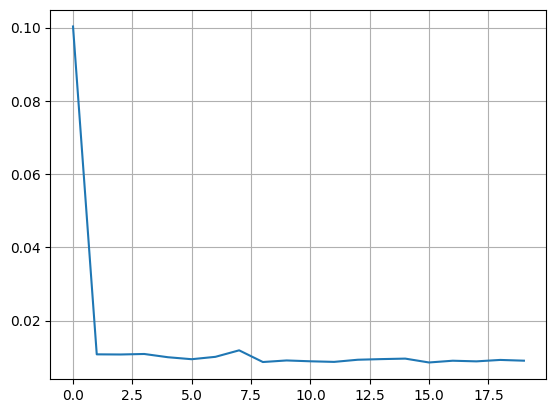

In [28]:
plt.plot(train_loss_list)
plt.grid()
plt.show()

In [29]:
#예측 데이터
model.eval()
preds=[]
trues=[]
with torch.no_grad():
    for x, y in test_dl:
        x=x.float()
        y=y.float()
        pred=model(x)
        preds.append(pred)
        trues.append(y)

preds

[tensor([[ 1.3344],
         [ 1.4210],
         [ 1.3599],
         [ 1.3623],
         [ 1.3598],
         [ 1.3802],
         [ 1.2419],
         [ 1.1976],
         [ 1.1634],
         [ 0.9693],
         [ 0.7466],
         [ 0.6163],
         [ 0.4356],
         [ 0.2204],
         [ 0.1495],
         [-0.0226],
         [-0.2628],
         [-0.4060],
         [-0.5156],
         [-0.6932],
         [-0.8247],
         [-0.9588],
         [-1.0836],
         [-1.2151],
         [-1.3428],
         [-1.3872],
         [-1.3415],
         [-1.4189],
         [-1.3944],
         [-1.4415],
         [-1.3473],
         [-1.2866],
         [-1.2212],
         [-1.1245],
         [-0.9646],
         [-0.8958],
         [-0.6295],
         [-0.5033],
         [-0.3341],
         [-0.1136],
         [ 0.1069],
         [ 0.2742],
         [ 0.4986],
         [ 0.6718],
         [ 0.7137],
         [ 0.8594],
         [ 1.0208],
         [ 1.0768],
         [ 1.1405],
         [ 1.2280],


In [30]:
preds=torch.cat(preds,0).squeeze(-1).numpy()
trues=torch.cat(trues,0).squeeze(-1).numpy()

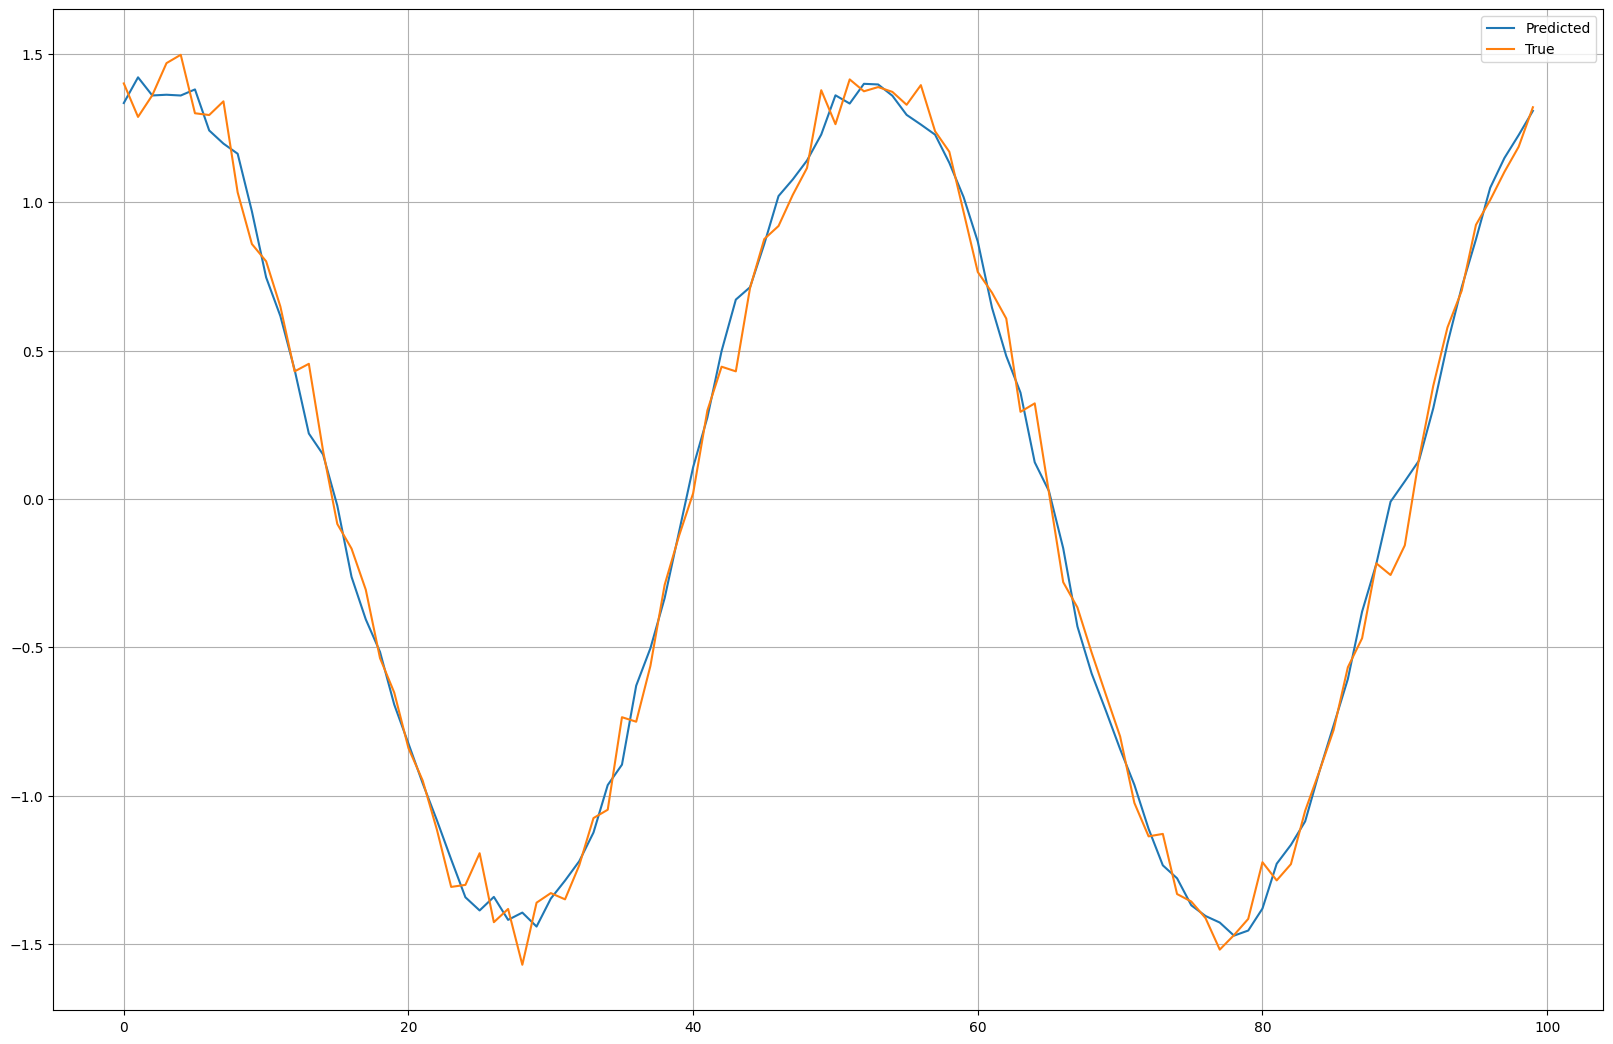

In [31]:
plt.figure(figsize=(20,13))
plt.plot(preds[:100],label='Predicted')
plt.plot(trues[:100],label='True')
plt.legend()
plt.grid()
plt.show()